# Spectral Cutting EDA

In [1]:
import os
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import loompy
import networkx as nx
from IPython.display import display

# Load Networks

In [2]:
# Dictionary to store data
data = {}

## SCENIC

In [3]:
# Set base path
base_path = '/scratch/indikar_root/indikar1/shared_data/scenic/hsc'

# Find all cluster folders
cluster_dirs = sorted(glob.glob(os.path.join(base_path, 'hsc_c*')))
print(f"Found {len(cluster_dirs)} cluster directories.")

scenic_data = {}
for cluster_path in cluster_dirs:
    cluster_name = os.path.basename(cluster_path)    
    adj_file = os.path.join(cluster_path, 'adj.tsv')
    
    # Load adjacency file
    adj_df = pd.read_csv(adj_file, sep='\t') # , header=None, names=['TF', 'Target', 'Importance'])
    adj_df.columns = ["n1", "n2", "weight"]
    
    # Store in dictionary
    scenic_data[cluster_name] = {
        'adjacency_list': adj_df,
    }

Found 5 cluster directories.


In [4]:
scenic_data.keys()

dict_keys(['hsc_c1', 'hsc_c2', 'hsc_c3', 'hsc_c4', 'hsc_c5'])

## scMINER

In [38]:
scminer_files = [
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C1/output/consensus_network_ncol_.txt",
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C2/output/consensus_network_ncol_.txt",
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C3/output/consensus_network_ncol_.txt",
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C4/output/consensus_network_ncol_.txt",
    "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/C5/output/consensus_network_ncol_.txt"
]

scminer_data = {}
key_names = ['hsc_c1', 'hsc_c2', 'hsc_c3', 'hsc_c4', 'hsc_c5']
for ifile, file in enumerate(scminer_files):
    adj_df = pd.read_csv(file, sep='\t')
    adj_df = adj_df[["source", "target"]]
    adj_df.columns = ['n1', 'n2']
    adj_df['weight'] = 1
    scminer_data[key_names[ifile]] = {
        'adjacency_list': adj_df,
    }

In [39]:
scminer_data.keys()

dict_keys(['hsc_c1', 'hsc_c2', 'hsc_c3', 'hsc_c4', 'hsc_c5'])

In [40]:
data = {
    "scenic": scenic_data,
    "scminer": scminer_data
}

# CellMarker_2024 Gene Lists

In [41]:
first_column, second_column = [], []
with open("../../resources/CellMarker_2024.txt", "r") as file:
    for line in file:
        # Split on tabs and remove empty strings
        parts = [p for p in line.strip().split('\t') if p]
        if not parts:
            continue
        first_column.append(parts[0])
        second_column.append(parts[1:])  # Everything after the first element

cell_marker_genes = pd.DataFrame({
    'cell_type': first_column,
    'marker_genes': second_column
})

hsc_markers = cell_marker_genes[cell_marker_genes['cell_type'] == "Hematopoietic Stem Cell Bone Marrow Human"]['marker_genes'].values[0]

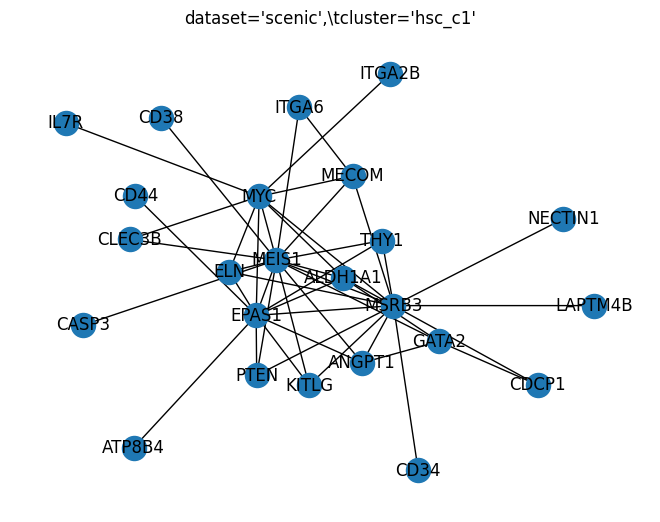

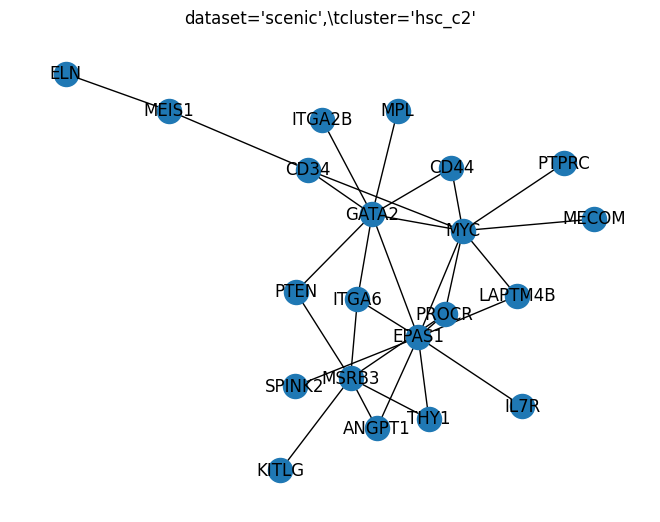

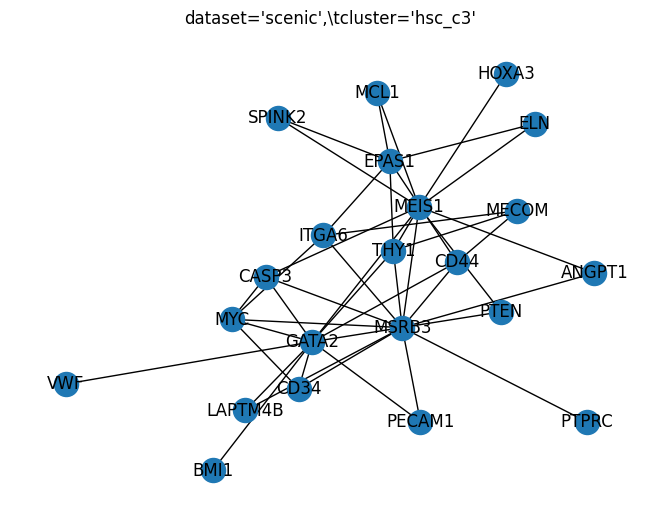

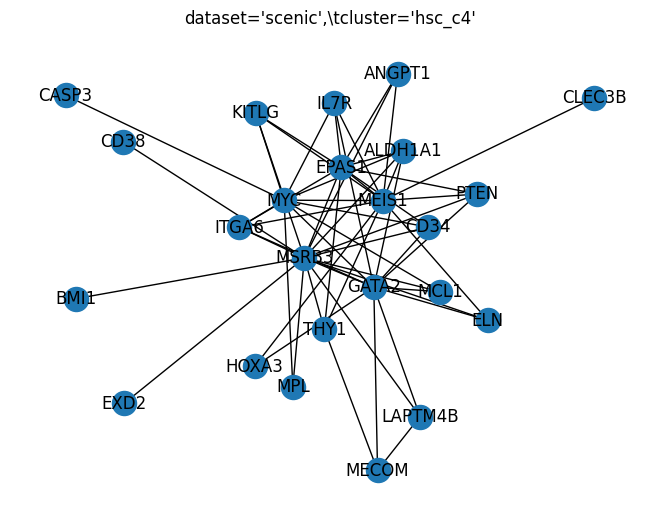

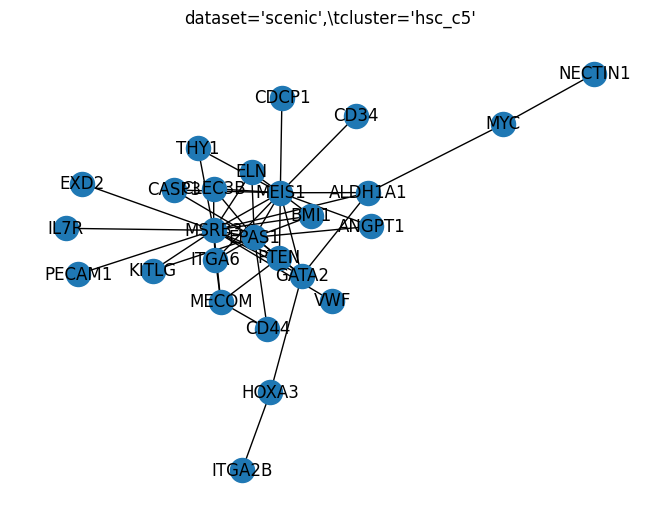

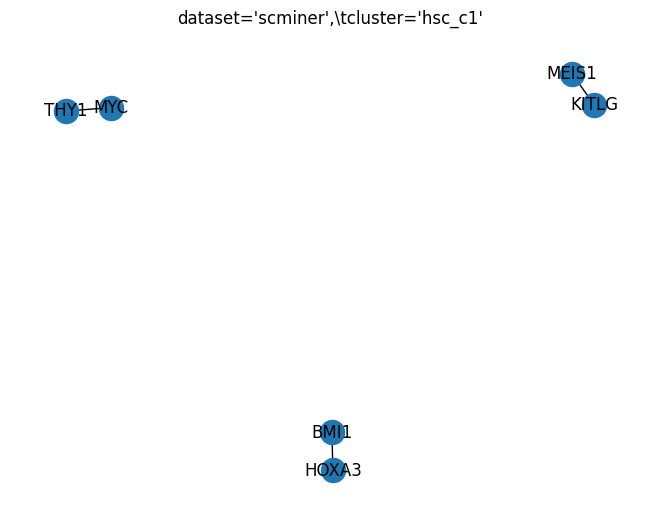

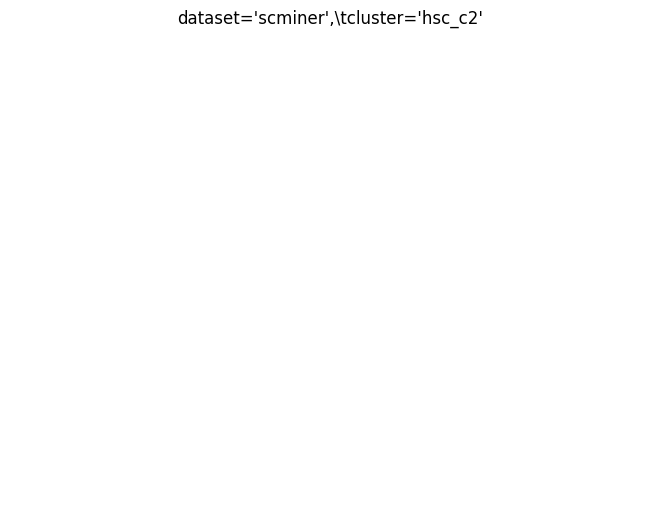

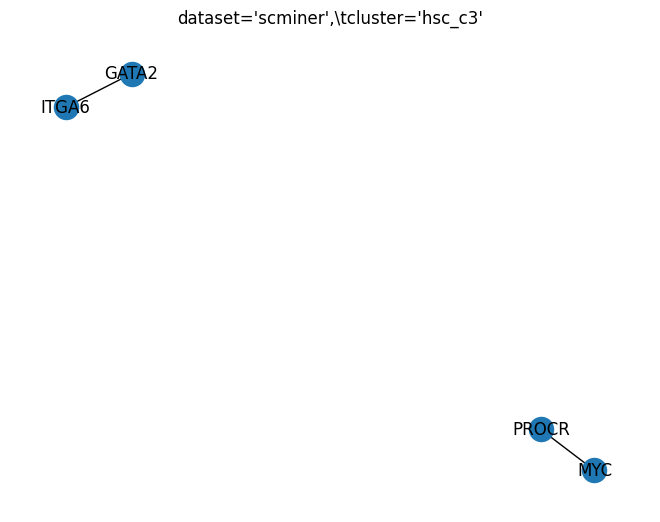

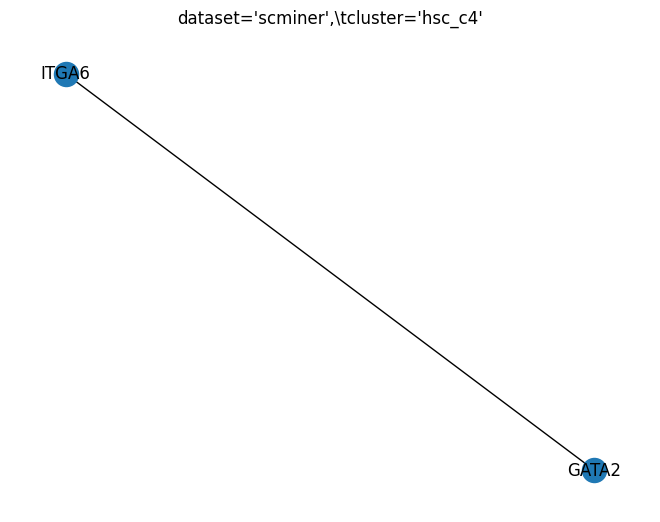

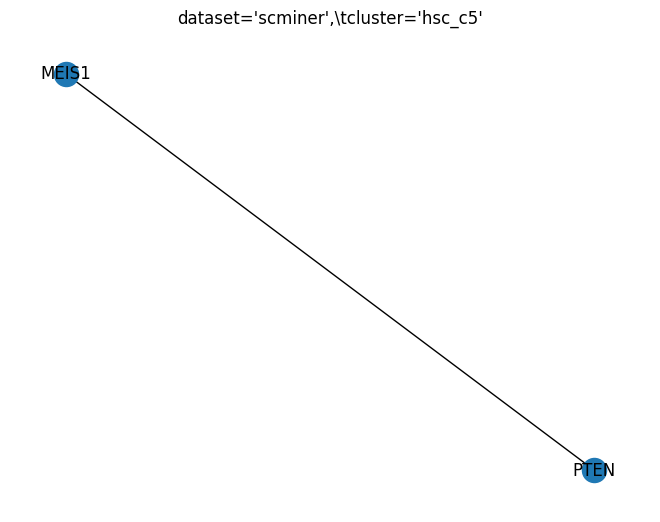

In [61]:
for dataset, cluster in ((d, c) for d in data for c in data[d]):
    adj_df = data[dataset][cluster]["adjacency_list"]
    gene_target_adj_df = adj_df[adj_df['n1'].isin(hsc_markers) & adj_df['n2'].isin(hsc_markers)]
    
    G = nx.Graph()  # or nx.DiGraph()
    edges = gene_target_adj_df[['n1', 'n2']].itertuples(index=False, name=None)
    G.add_edges_from(edges)
    nx.draw(G, with_labels=True)
    plt.title(f"{dataset=},\\t{cluster=}")
    plt.show()

In [55]:
G = nx.Graph()  # or nx.DiGraph()
edges = gene_target_adj_df[['n1', 'n2']].itertuples(index=False, name=None)
G.add_edges_from(edges)
nx.draw(G, with_labels=True)

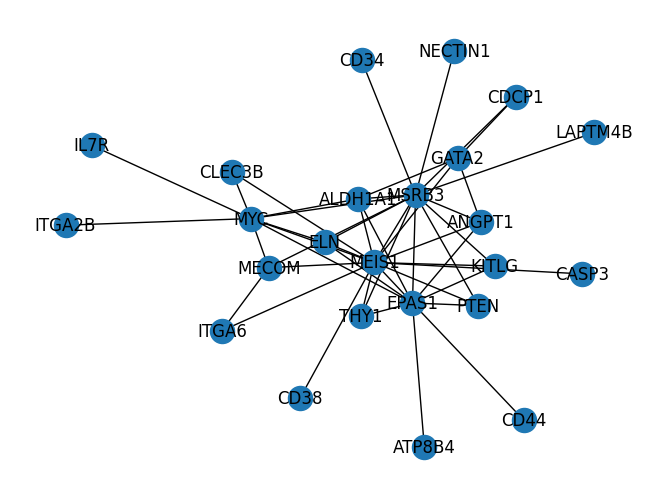

In [59]:
nx.draw(G, with_labels=True)